<a href="https://colab.research.google.com/github/petrovortex/foundations_of_ml_course/blob/main/hometask_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/alex-petrov-git/datatools.git

import sys
sys.path.append('/content/datatools')

Cloning into 'datatools'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.


In [ ]:
from explorator import DataExplorator
from sklearn.model_selection import train_test_split

In [ ]:
df_train = pd.read_csv("/content/train.csv")
X_test = pd.read_csv("/content/test.csv")

In [ ]:
y = df_train['price']
X = df_train.drop(labels=['price'], axis=1)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=4)

In [ ]:
X_train.sample(5)

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
1046,1047,Volkswagen,Arteon SEL R-Line,2022,"18,655 mi.",Gasoline,2.0 Liter TSI,Automatic,Oryx White Prl,Titan Black,None reported,NaN
2238,2239,Nissan,Pathfinder SL,2015,"115,000 mi.",Gasoline,260.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,None reported,Yes
2282,2283,Ford,Expedition Limited,2013,"163,500 mi.",E85 Flex Fuel,310.0HP 5.4L 8 Cylinder Engine Flex Fuel Capab...,A/T,Gray,Black,None reported,Yes
521,522,Ford,Transit-350 Base,2018,"235,000 mi.",Gasoline,275.0HP 3.7L V6 Cylinder Engine Gasoline Fuel,A/T,White,Gray,NaN,NaN
2637,2638,Hummer,H3 Base,2010,"107,481 mi.",Gasoline,239.0HP 3.7L 5 Cylinder Engine Gasoline Fuel,A/T,White,Black,None reported,Yes


## 1. EDA

In [ ]:
explorator = DataExplorator()

In [ ]:
explorator.get_info(df_train)

,Type,Count,Nunique,Nulls,Most frequent
id,int64,3009,3009,0,"[3009, 2993, 2992]"
brand,object,3009,56,0,"[BMW, Ford, Mercedes-Benz]"
model,object,3009,1576,0,"[Corvette Base, M3 Base, Model Y Long Range]"
model_year,int64,3009,34,0,"[2021, 2022, 2018]"
milage,object,3009,2190,0,"[110,000 mi., 55,000 mi., 45,000 mi.]"
fuel_type,object,3009,7,121,"[Gasoline, Hybrid, E85 Flex Fuel]"
engine,object,3009,1005,0,"[2.0L I4 16V GDI DOHC Turbo, 355.0HP 5.3L 8 Cy..."
transmission,object,3009,60,0,"[A/T, 8-Speed A/T, Transmission w/Dual Shift M..."
ext_col,object,3009,260,0,"[Black, White, Gray]"
int_col,object,3009,130,0,"[Black, Beige, Gray]"


In [ ]:
explorator.get_info(X_test)

,Type,Count,Nunique,Nulls,Most frequent
id,int64,1000,1000,0,"[4009, 3010, 3011]"
brand,object,1000,50,0,"[Ford, BMW, Chevrolet]"
model,object,1000,747,0,"[M3 Base, F-150 XLT, 1500 Laramie]"
model_year,int64,1000,31,0,"[2020, 2022, 2021]"
milage,object,1000,846,0,"[65,000 mi., 40,000 mi., 22,000 mi.]"
fuel_type,object,1000,6,49,"[Gasoline, Hybrid, E85 Flex Fuel]"
engine,object,1000,563,0,"[2.0L I4 16V GDI DOHC Turbo, 420.0HP 6.2L 8 Cy..."
transmission,object,1000,35,0,"[A/T, Transmission w/Dual Shift Mode, 8-Speed ..."
ext_col,object,1000,121,0,"[Black, White, Gray]"
int_col,object,1000,65,0,"[Black, Gray, Beige]"


In [ ]:
explorator.print_top_values_info(df_train, 7)

  id: value  id: freq   brand: value  brand: freq        model: value  \
0      3009         1            BMW          289       Corvette Base   
1      2993         1           Ford          288             M3 Base   
2      2992         1  Mercedes-Benz          247  Model Y Long Range   
3      2991         1      Chevrolet          215           F-150 XLT   
4      2990         1        Porsche          147         911 Carrera   
5      2989         1           Audi          141          Camaro 2SS   
6      2988         1         Toyota          137      Wrangler Sport   

   model: freq model_year: value  model_year: freq milage: value  \
0           18              2021               270   110,000 mi.   
1           17              2022               267    55,000 mi.   
2           16              2018               243    45,000 mi.   
3           16              2020               235    44,000 mi.   
4           15              2019               228   120,000 mi.   
5      

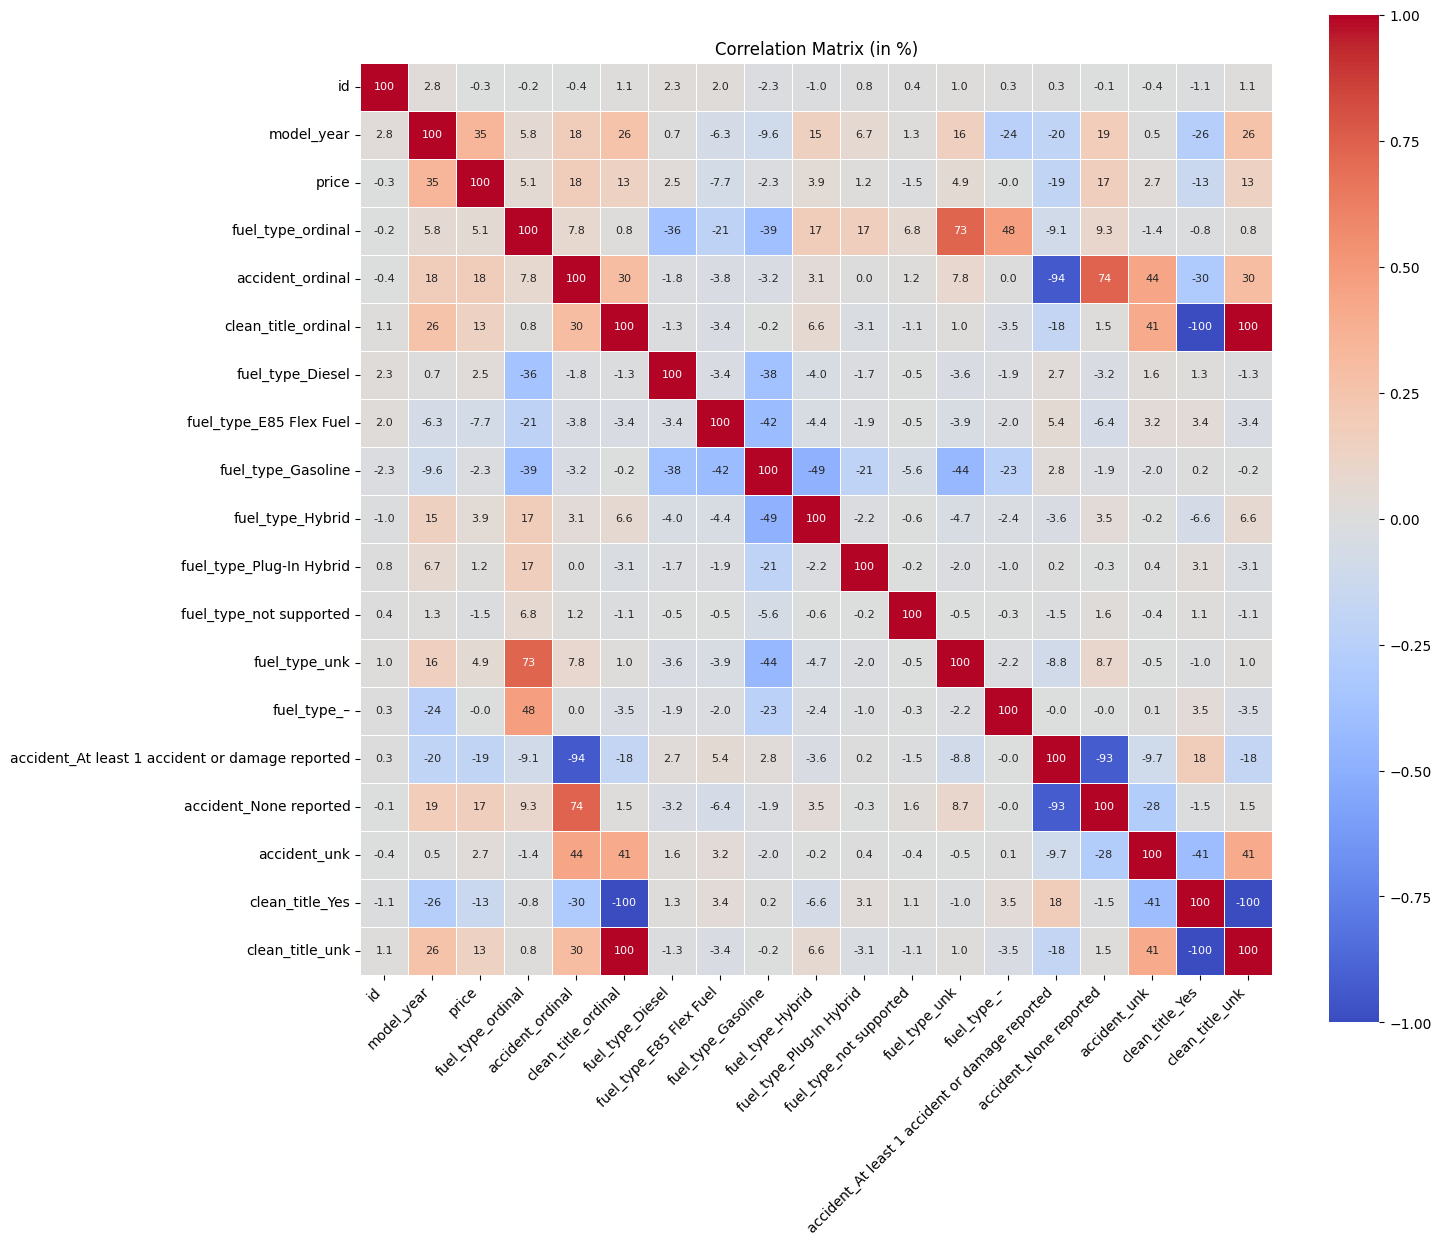

In [ ]:
corr, df_encoded = explorator.get_correlations(df_train)

## 2. Data preprocessing

In [ ]:
import re
from collections import Counter

def extract_frequent_words(df, column, min_freq=20):
    words = []
    df_nona = df[column].dropna()
    for val in df_nona:
        words.extend(re.findall(r"[A-Za-z0-9]+", val.lower()))

    word_counts = Counter(words)
    frequent_words = [ (w, c) for w, c in word_counts.items() if c >= min_freq]
    frequent_words.sort(key=lambda x: x[1], reverse=True)

    print(f"Найдено {len(frequent_words)} частых слов: {frequent_words}")

    return [w[0] for w in frequent_words]

In [ ]:
key_words_model = extract_frequent_words(X_train, 'model', min_freq=15)
key_words_engine = extract_frequent_words(X_train, 'engine', min_freq=30)
key_words_brand = extract_frequent_words(X_train, 'brand', min_freq=15)
key_words_ext_col = extract_frequent_words(X_train, 'ext_col', min_freq=15)
key_words_int_col = extract_frequent_words(X_train, 'int_col', min_freq=15)

Найдено 108 частых слов: [('base', 416), ('s', 178), ('premium', 162), ('rover', 143), ('sport', 128), ('class', 124), ('2', 108), ('f', 106), ('i', 103), ('3', 102), ('4matic', 91), ('1500', 91), ('range', 91), ('0t', 88), ('350', 78), ('e', 74), ('limited', 72), ('gt', 64), ('xdrive', 59), ('plus', 59), ('amg', 57), ('c', 57), ('xlt', 56), ('se', 55), ('model', 54), ('2500', 53), ('wrangler', 52), ('911', 52), ('250', 52), ('touring', 49), ('r', 49), ('platinum', 46), ('hybrid', 46), ('corvette', 43), ('150', 43), ('300', 41), ('carrera', 39), ('mustang', 39), ('5', 37), ('edition', 37), ('luxury', 36), ('w', 35), ('4', 34), ('silverado', 32), ('grand', 32), ('sl', 31), ('line', 31), ('lt', 31), ('escalade', 31), ('ex', 30), ('hse', 28), ('turbo', 28), ('package', 28), ('camaro', 27), ('x', 27), ('lariat', 27), ('long', 27), ('63', 26), ('x5', 26), ('lx', 25), ('suburban', 25), ('unlimited', 25), ('rx', 24), ('slt', 24), ('l', 24), ('0l', 23), ('gl', 23), ('coupe', 23), ('supercharge

In [ ]:
def filter_by_substring(df: pd.DataFrame, feature: str, substr: str, case: bool = False) -> pd.DataFrame:
    mask = df[feature].astype(str).str.contains(rf'\b{substr}\b', case=case, na=False)
    return df[mask]

In [ ]:
filter_by_substring(X_train, 'model', 's')

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
1283,1284,Mercedes-Benz,CLS-Class CLS 63 AMG S-Model 4MATIC,2014,"64,500 mi.",Gasoline,577.0HP 5.5L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,Silver,Black,NaN,NaN
764,765,Land,Rover Range Rover Velar P380 S,2018,"46,000 mi.",Gasoline,380.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,A/T,Red,Beige,None reported,Yes
1837,1838,Mercedes-Benz,AMG C AMG C 63 S,2016,"40,515 mi.",Gasoline,4.0L V8 32V GDI DOHC Twin Turbo,7-Speed Automatic,Black,Black,At least 1 accident or damage reported,NaN
2147,2148,Nissan,Xterra S,2007,"132,272 mi.",Gasoline,261.0HP 4.0L V6 Cylinder Engine Gasoline Fuel,M/T,Gray,Gray,At least 1 accident or damage reported,Yes
2240,2241,Mercedes-Benz,S-Class S 560 4MATIC,2019,"49,500 mi.",Gasoline,463.0HP 4.0L 8 Cylinder Engine Gasoline Fuel,A/T,Black,Beige,None reported,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...
64,65,Mercedes-Benz,AMG C 63 S,2017,"34,500 mi.",Gasoline,503.0HP 4.0L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,Gray,Black,None reported,Yes
878,879,Nissan,Rogue Sport S,2021,"24,000 mi.",Gasoline,141.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,None reported,Yes
1579,1580,Tesla,Model S 90D,2016,"74,122 mi.",NaN,417.0HP Electric Motor Electric Fuel System,A/T,Black,Black,None reported,Yes
1478,1479,Jeep,Gladiator Sport S,2022,"23,000 mi.",Gasoline,285.0HP 3.6L V6 Cylinder Engine Gasoline Fuel,A/T,Green,Black,None reported,Yes


In [ ]:
import pandas as pd

def print_value_counts(df: pd.DataFrame, feature: str) -> None:

    print(f"\n📊 Частоты значений для признака '{feature}':")
    print("-" * 50)

    counts = df[feature].value_counts(dropna=False)
    for val, freq in counts.items():
        print(f"{val!r:<20} → {freq}")

Какие колонки нужно обработать:


1. model, engine, transmission: выделить новые признаки, сгруппировав уникальные значения по ключевым словам:
    - transmission: is_manual (M/T, manual), is_automatic (A/T, automatic), is_cvt (cvt), speed (speed, spd)
    - engine:

2. fuel_type заполнить пропуски unknown и сделать onehot

3. model_year просто нормализовать (а можно разбить на пятилетки для классических моделей)

4. milage выделить число

5. ext_col, int_col, brand выделить самые популярные (штук 10-15) остальные собрать в одну категорию.

6. accident заполнить пропуски медианой и бинаризовать

7. clean_title заполнить пропуски "No" и бинаризовать.



In [ ]:
import numpy as np
import re
from collections import Counter
from sklearn.preprocessing import StandardScaler, OneHotEncoder

class CarPreprocessor:
    def __init__(self, color_min_freq=15, brand_min_freq=15):
        self.color_min_freq = color_min_freq
        self.brand_min_freq = brand_min_freq
        self.scaler = StandardScaler()
        self.encoder_fuel = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
        self.frequent_values = {}
        self.trans_speed_median = None

    def _extract_frequent_words(self, df, column):
        words = []
        df_nona = df[column].dropna()
        for val in df_nona:
            words.extend(re.findall(r"[A-Za-z0-9]+", val.lower()))
        counts = Counter(words)
        return [w for w, c in counts.items() if c >= self.color_min_freq]

    def _preprocess_core(self, df, fit=False):
        df = df.copy()
        df = df.drop(labels=['id'], axis=1)

        if fit:
            df['fuel_type'] = df['fuel_type'].fillna('unknown')
            self.encoder_fuel.fit(df[['fuel_type']])
        fuel_encoded = self.encoder_fuel.transform(df[['fuel_type']].fillna('unknown'))
        fuel_df = pd.DataFrame(fuel_encoded, columns=self.encoder_fuel.get_feature_names_out(['fuel_type']), index=df.index)

        df['milage_num'] = df['milage'].str.replace(',', '').str.extract(r'(\d+)').astype(float)
        df = df.drop(labels=['milage'], axis=1)
        df['milage_num'] = df['milage_num'].fillna(df['milage_num'].median())

        for col in ['ext_col', 'int_col', 'brand']:
            if fit:
                self.frequent_values[col] = self._extract_frequent_words(df, col)
            frequent = self.frequent_values[col]
            df[col] = df[col].fillna('').str.lower()
            for word in frequent:
                df[f"{col}_{word}"] = df[col].apply(lambda x: 1 if word in x else 0)
            df[f"{col}_other"] = df[[f"{col}_{w}" for w in frequent]].sum(axis=1).apply(lambda x: 1 if x == 0 else 0)

        df['is_manual'] = df['transmission'].str.contains(r'(?:m/t|manual)', case=False, na=False).astype(int)
        df['is_automatic'] = df['transmission'].str.contains(r'(?:a/t|automatic)', case=False, na=False).astype(int)
        df['is_cvt'] = df['transmission'].str.contains(r'cvt', case=False, na=False).astype(int)
        df['trans_speed'] = df['transmission'].str.extract(r'(\d+)\s*[- ]?\s*(?:speed|spd)', flags=re.IGNORECASE)[0].astype(float)
        if fit:
            self.trans_speed_median = df['trans_speed'].median()
        df['trans_speed'] = df['trans_speed'].fillna(self.trans_speed_median)

        hp = df['engine'].str.extract(r'(\d+(?:\.\d+)?)\s*HP', flags=re.IGNORECASE)[0].astype(float)
        liters = df['engine'].str.extract(r'(\d+(?:\.\d+)?)\s*(?:L|Liter)', flags=re.IGNORECASE)[0].astype(float)

        if fit:
            self.median_hp = hp.median()
            self.median_liters = liters.median()

        df['hp'] = hp.fillna(self.median_hp)
        df['liters'] = liters.fillna(self.median_liters)

        features_to_scale = ['model_year', 'trans_speed', 'hp', 'liters', 'milage_num']

        if fit:
            self.scaler.fit(df[features_to_scale])
        df['model_year'] = self.scaler.transform(df[features_to_scale])

        gasoline_mask = df['engine'].str.contains('gasoline', case=False, na=False)
        diesel_mask = df['engine'].str.contains('diesel', case=False, na=False)

        fuel_df.loc[gasoline_mask, 'fuel_type_Gasoline'] = 1
        df['fuel_type_Diesel'] = diesel_mask.astype(int)

        keywords = ['base', 'premium', 'rover', 'sport', 'luxury', 'limited', 'plus', 'platinum', 'prestige', 's']
        for kw in keywords:
            df[f'is_{kw}'] = df['model'].str.contains(rf'\b{kw}\b', case=False, na=False).astype(int)

        df['accident'] = df['accident'].fillna(df['accident'].mode()[0])
        df['accident'] = df['accident'].apply(lambda x: 1 if 'none' not in str(x).lower() else 0)
        df['clean_title'] = df['clean_title'].fillna('No').apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

        df = pd.concat([df, fuel_df], axis=1)

        df = df.drop(labels=['model', 'transmission', 'engine',
                             'ext_col', 'int_col', 'brand',
                             'fuel_type', 'fuel_type_not supported',
                             'fuel_type_unknown', 'fuel_type_–'], axis=1)

        return df

    def fit_transform(self, df):
        return self._preprocess_core(df, fit=True)

    def transform(self, df):
        return self._preprocess_core(df, fit=False)


In [ ]:
preprocessor = CarPreprocessor()

In [ ]:
X_train_prep = preprocessor.fit_transform(X_train) # X_train for testing

In [ ]:
X_val_prep = preprocessor.transform(X_val)

In [ ]:
X_test_prep = preprocessor.transform(X_test)

## 3. Training and testing

In [ ]:
! pip install tabpfn-extensions[all]
! pip install tabpfn

Using Python 3.12.12 environment at: /usr
Audited 1 package in 297ms
Using Python 3.12.12 environment at: /usr
Audited 1 package in 193ms


In [ ]:
from tabpfn import TabPFNRegressor

In [ ]:
tabpfn_regressor = TabPFNRegressor(random_state=42)
tabpfn_regressor.fit(X_train_prep, y_train)

TabPFNRegressor(random_state=42)

In [ ]:
out = tabpfn_regressor.predict(X_val_prep, output_type="full")
criterion, logits = out["criterion"], out["logits"]

q = np.linspace(0.01, 0.99, 101)
samples = np.stack(
    [criterion.icdf(logits, float(x)).cpu().numpy() for x in q], axis=1
)

denom = np.maximum(np.abs(samples), 1e-6)
diffs = np.abs(samples[:, :, None] - samples[:, None, :])
exp_mape = (diffs / denom[:, :, None]).mean(axis=1)

best_idx = exp_mape.argmin(axis=1)

y_hat = samples[np.arange(samples.shape[0]), best_idx]

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

y_true = y_val.values if hasattr(y_val, 'values') else y_val
y_pred = y_hat.values if hasattr(y_hat, 'values') else y_hat

mape_score = mean_absolute_percentage_error(y_true, y_pred) * 100
print(f"MAPE: {mape_score:.2f}%")

MAPE: 17.12%


In [ ]:
submission = pd.DataFrame({
    'id': X_test['id'],
    'price': y_hat
})

submission.to_csv('submission.csv', index=False)